In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/suicides_in_india_cleaned_data.csv')


In [3]:
data=data[data.loc[:,'type_code']=='Causes']

# we are filtering our data because it has 3 times duplication by type codes

In [4]:
plt.style.use('classic')

##1. State, year, gender, and age-group wise suicide records


In [5]:
state_vs_year=data.pivot_table(index='state',columns='year',values='total',aggfunc='sum')
state_vs_year

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
state,,,,,,,,,,,,
A & N Islands,129.0,144.0,113.0,122.0,139.0,133.0,156.0,143.0,131.0,156.0,136.0,121.0
Andhra Pradesh,10522.0,11693.0,11409.0,13526.0,13442.0,13276.0,14882.0,14354.0,14500.0,15901.0,15077.0,14238.0
Arunachal Pradesh,111.0,114.0,81.0,79.0,70.0,129.0,129.0,110.0,110.0,131.0,134.0,130.0
Assam,2647.0,2510.0,2596.0,2839.0,2846.0,3031.0,3062.0,2989.0,2966.0,2993.0,2726.0,3264.0
Bihar,603.0,720.0,599.0,351.0,543.0,618.0,965.0,1015.0,1051.0,1226.0,795.0,759.0
Chandigarh,70.0,87.0,103.0,75.0,89.0,80.0,82.0,83.0,75.0,71.0,105.0,114.0
Chhattisgarh,4025.0,3950.0,3919.0,4495.0,4881.0,4626.0,4839.0,4945.0,5883.0,6522.0,6756.0,5654.0
D & N Haveli,50.0,50.0,52.0,39.0,69.0,42.0,76.0,60.0,56.0,63.0,63.0,66.0
Daman & Diu,14.0,17.0,24.0,13.0,32.0,22.0,15.0,19.0,23.0,31.0,33.0,36.0


In [6]:
state_vs_gender=data.pivot_table(index='state',columns='gender',values='total',aggfunc='sum')
state_vs_gender

gender,Female,Male
state,,
A & N Islands,550,1073
Andhra Pradesh,54396,108424
Arunachal Pradesh,391,937
Assam,11031,23438
Bihar,4053,5192
Chandigarh,378,656
Chhattisgarh,19739,40756
D & N Haveli,280,406
Daman & Diu,95,184


In [7]:
state_vs_age_group=data.pivot_table(index='state',columns='age_group',values='total',aggfunc='sum')
state_vs_age_group

age_group,0-14,15-29,30-44,45-59,60+
state,,,,,
A & N Islands,53.0,630.0,464.0,311.0,165.0
Andhra Pradesh,3265.0,55121.0,56770.0,34917.0,12747.0
Arunachal Pradesh,49.0,572.0,524.0,160.0,23.0
Assam,734.0,13384.0,12747.0,6601.0,1003.0
Bihar,572.0,3720.0,3298.0,1241.0,414.0
Chandigarh,16.0,531.0,349.0,111.0,27.0
Chhattisgarh,2040.0,22048.0,19954.0,11907.0,4546.0
D & N Haveli,6.0,303.0,183.0,121.0,73.0
Daman & Diu,11.0,131.0,88.0,42.0,7.0


## #year, age-group vs suicide records trend for all states visuals

In [8]:
states=[]
years=[]
ages=[]
color_codes = ["#E6194B", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
               "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990", "#dcbeff",
               "#9A6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#ffd8b1",
               "#000075", "#a9a9a9", "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
               "#66a61e", "#e6ab02", "#a6761d", "#666666", "#1f78b4", "#33a02c",
               "#fb9a99", "#e31a1c", "#fdbf6f", "#cab2d6", "#ffff11"]
for state in state_vs_year.index:
  states.append(state)
for year in state_vs_year.columns:
  years.append(year)
for age in state_vs_age_group.columns:
  ages.append(age)
print(states)
print(years)
print(ages)


['A & N Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'D & N Haveli', 'Daman & Diu', 'Delhi (Ut)', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
[2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]
['0-14', '15-29', '30-44', '45-59', '60+']


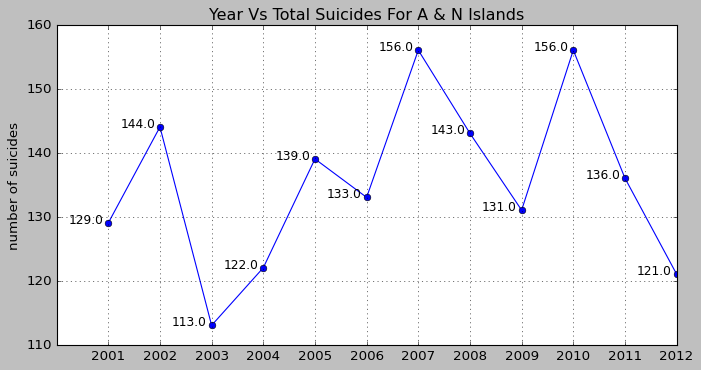

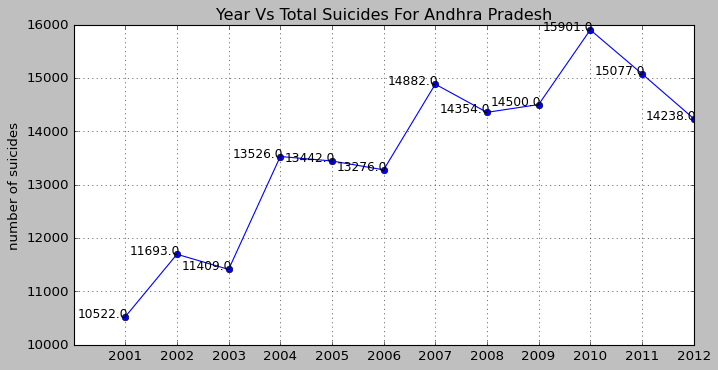

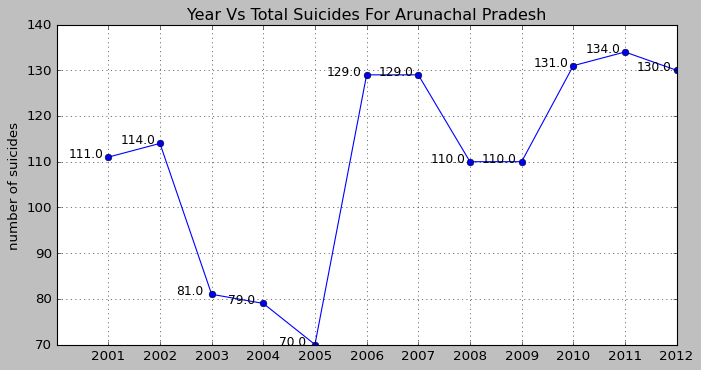

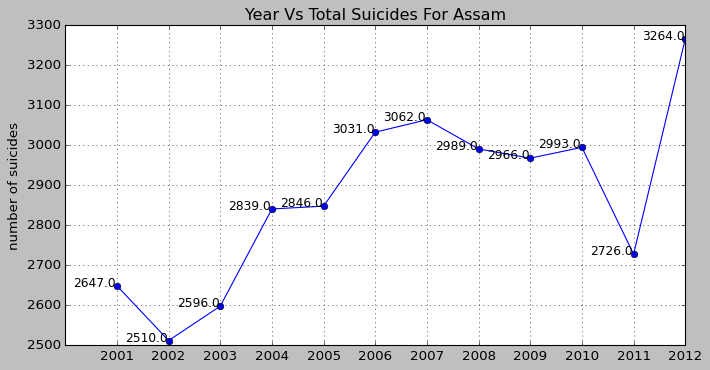

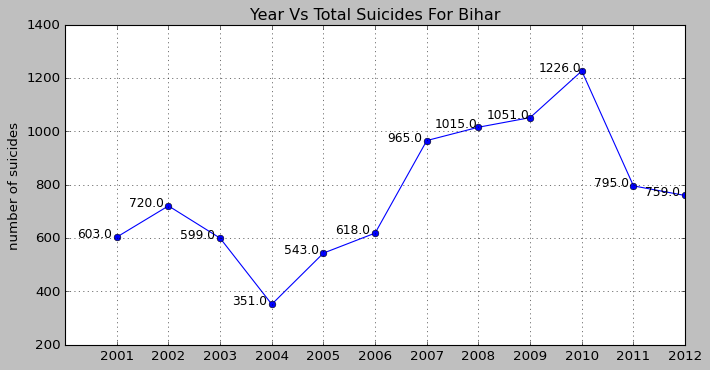

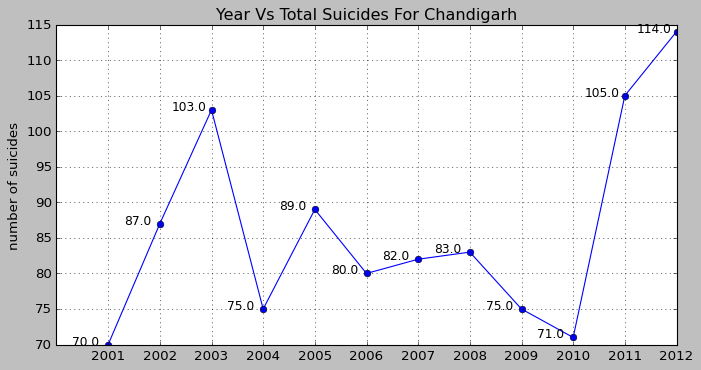

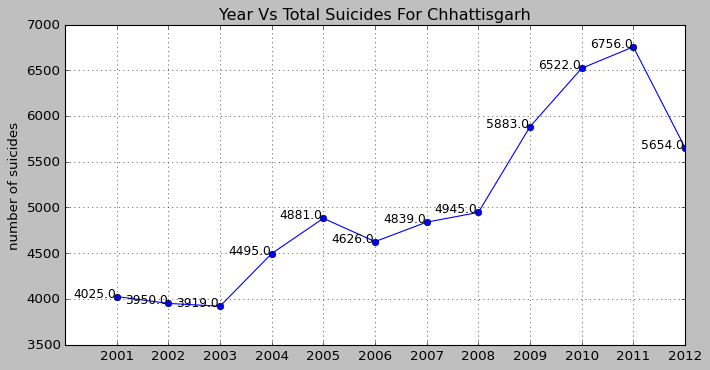

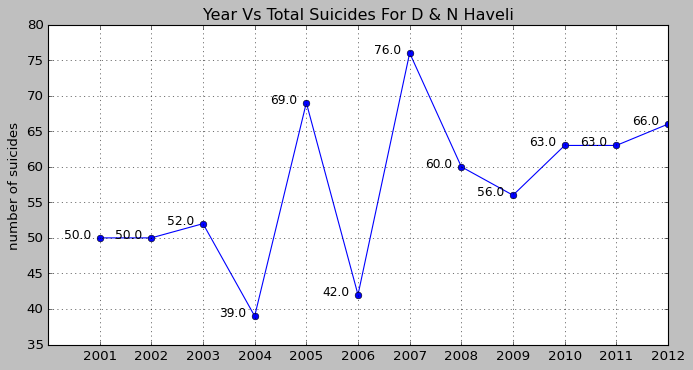

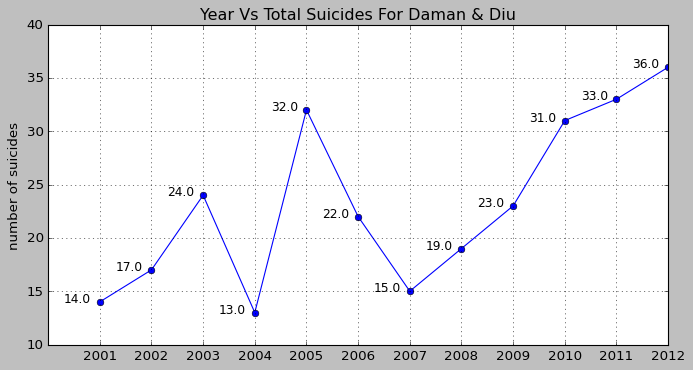

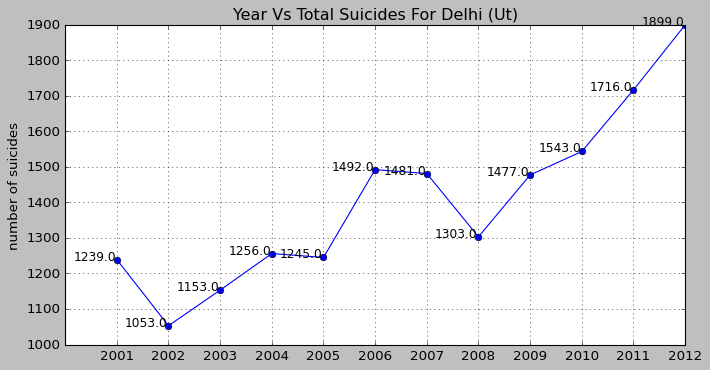

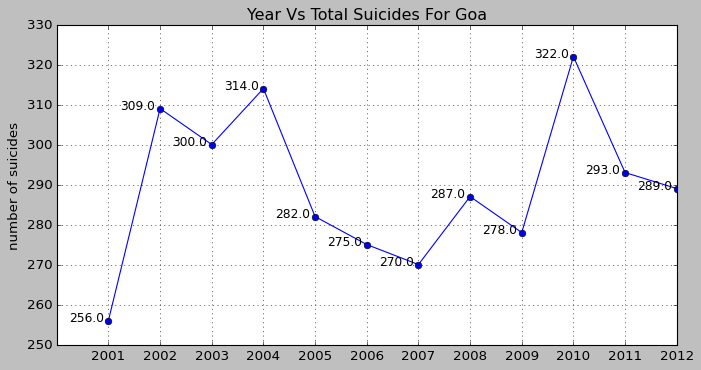

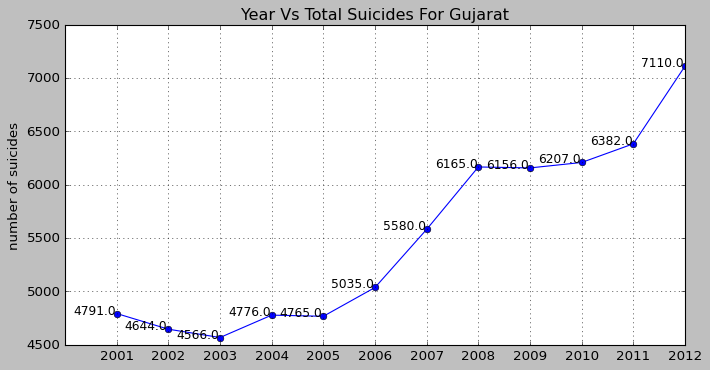

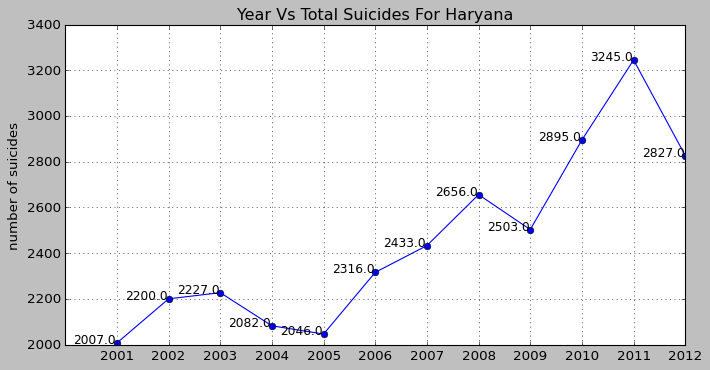

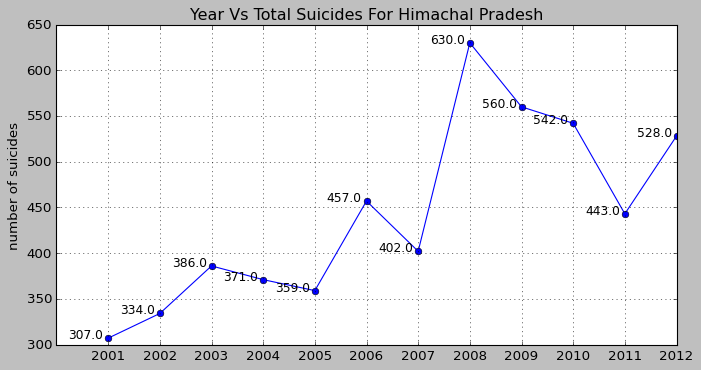

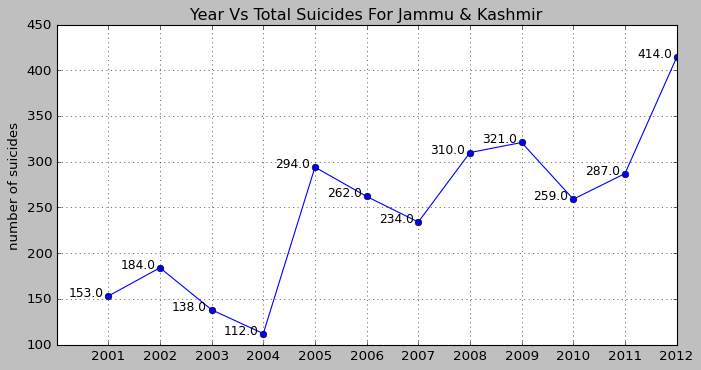

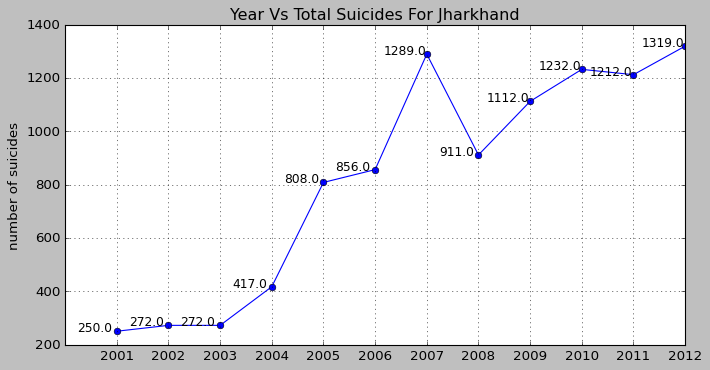

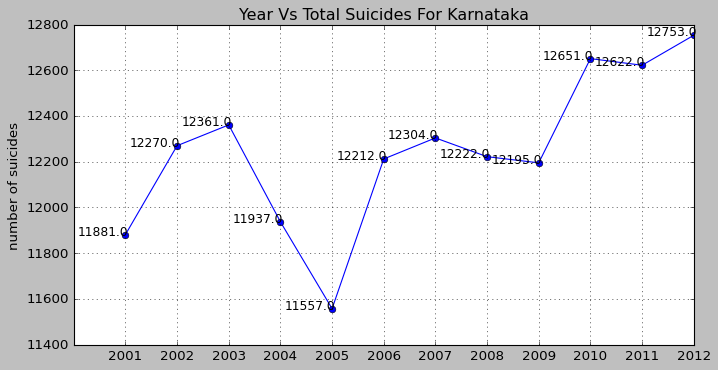

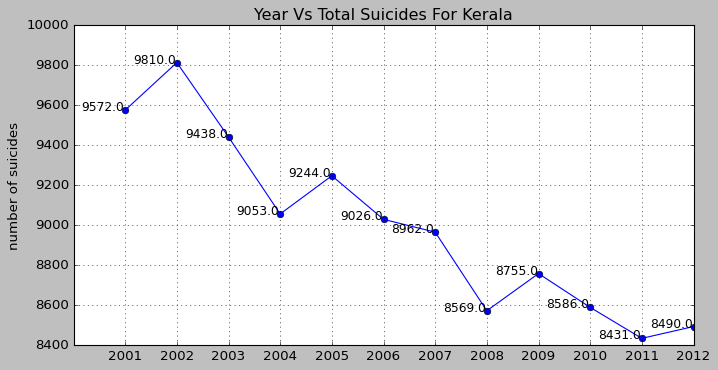

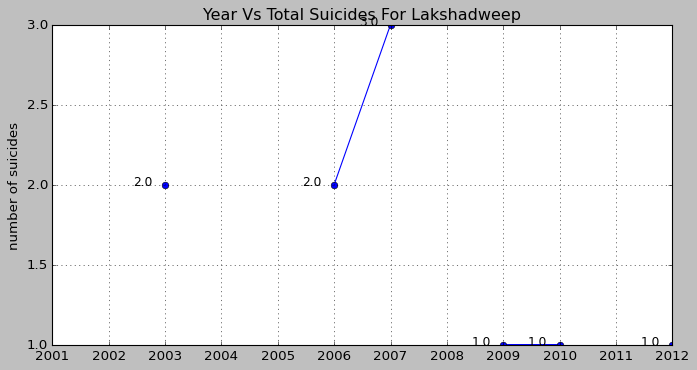

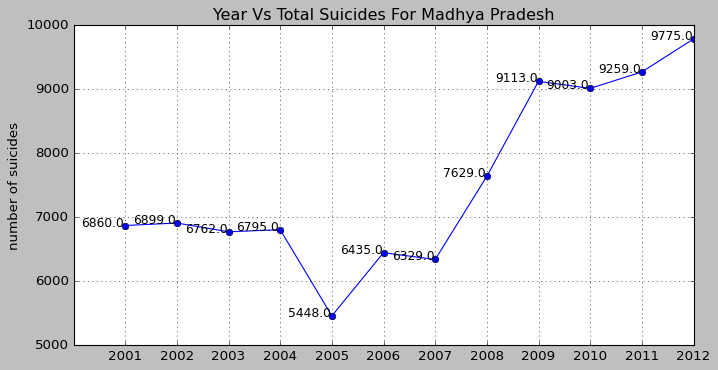

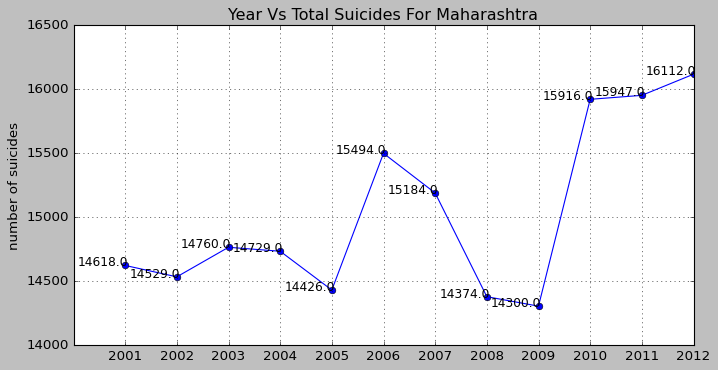

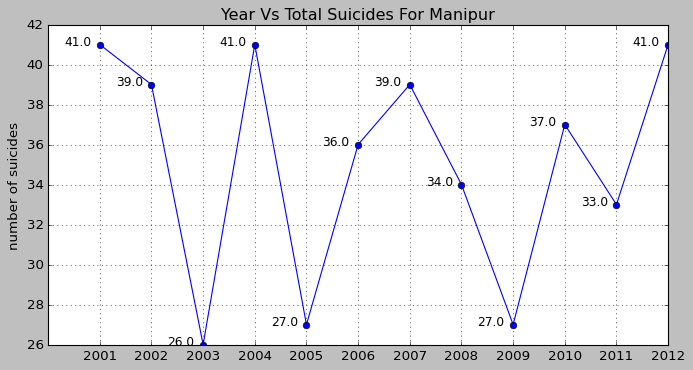

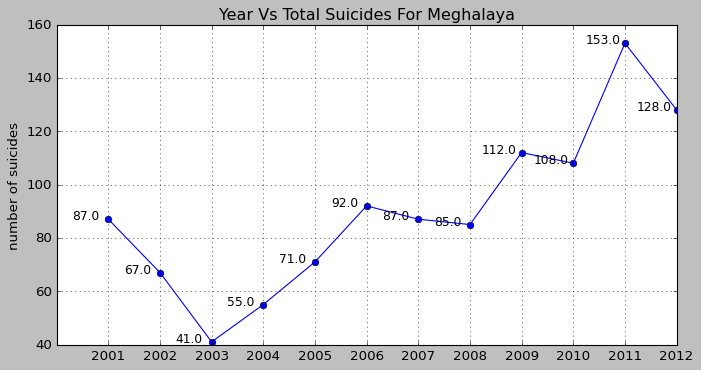

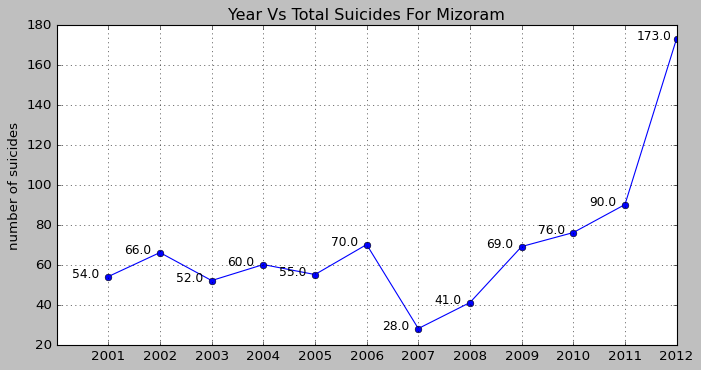

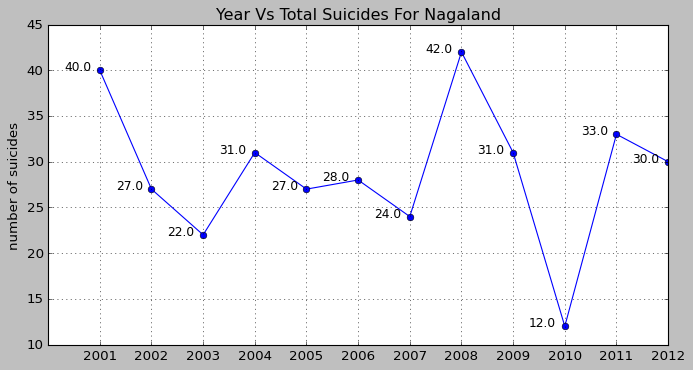

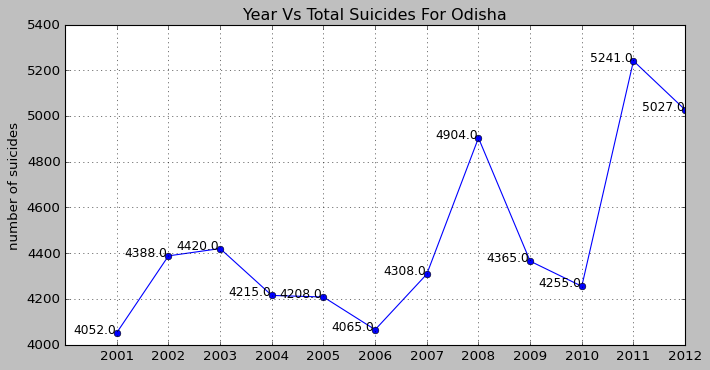

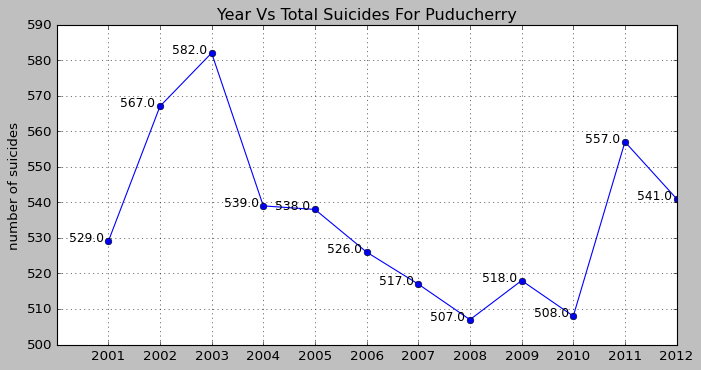

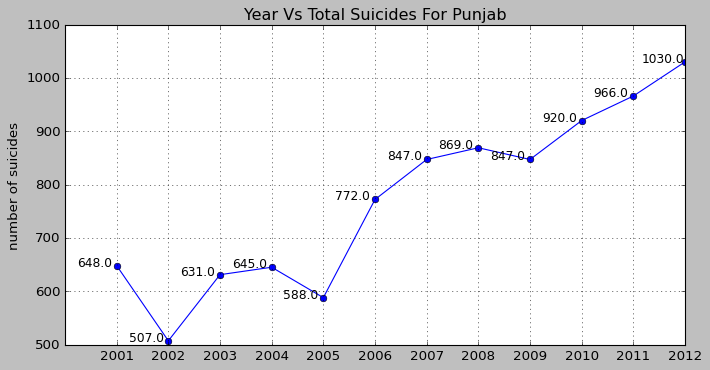

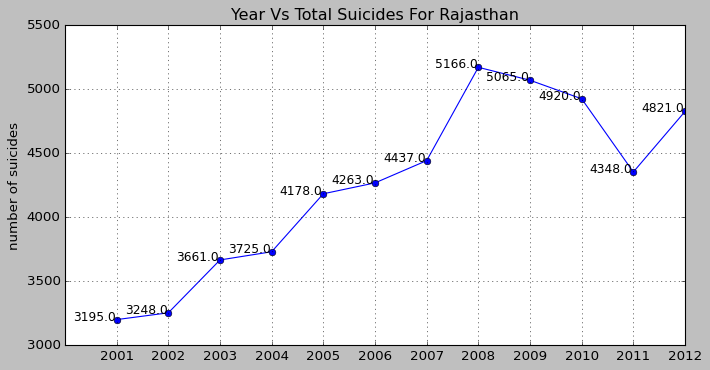

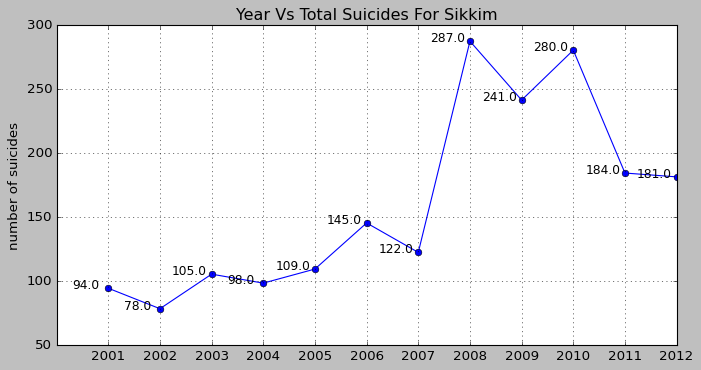

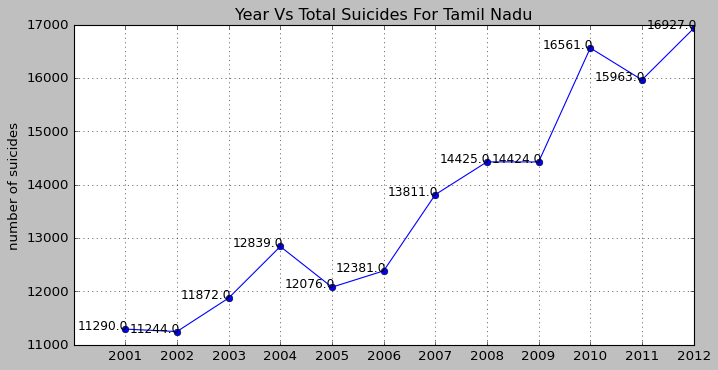

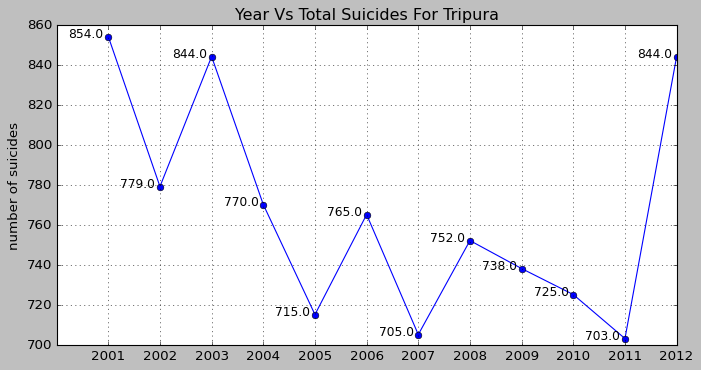

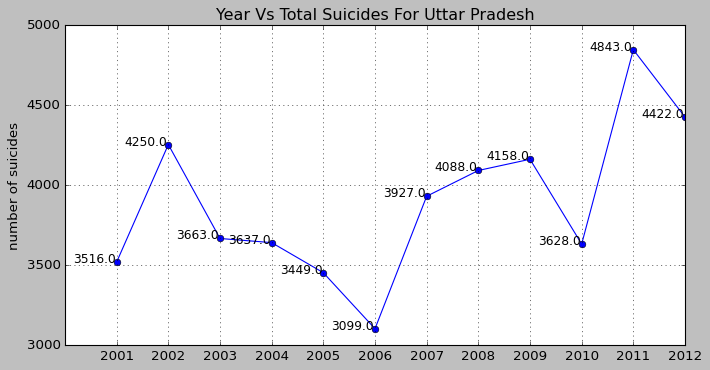

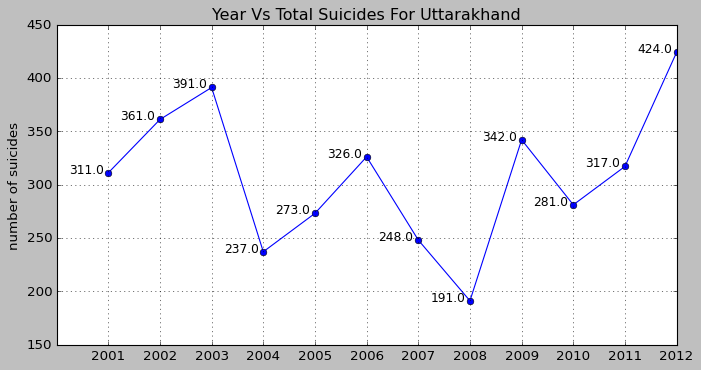

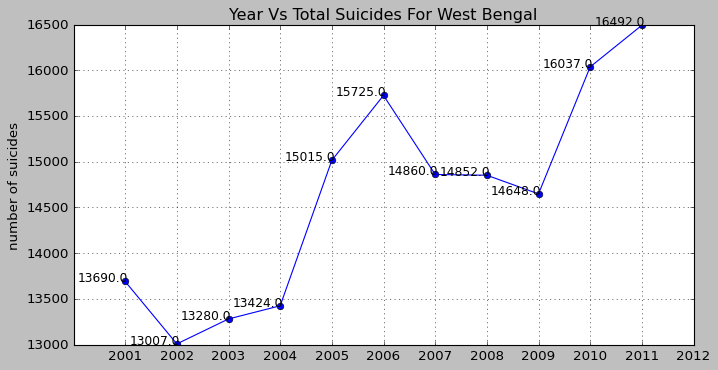

In [9]:

for s in states:
  y=state_vs_year.loc[s]
  x=years
  plt.figure(figsize=(10,5))
  plt.plot(x,y,marker='o')

  for xi, yi in zip(x, y):
        plt.annotate(text=str(yi), xy=(xi, yi), textcoords="offset points", xytext=(-20,0), ha='center', fontsize=11)

  plt.xticks(x,x)
  plt.title(f'Year Vs Total Suicides For {s}')
  plt.ylabel('number of suicides')
  plt.grid()
  #plt.savefig(f'/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/year vs total suicides for all states/Year_Vs_Total_Suicides_For_{s.replace(" ","_")}')
  plt.show()


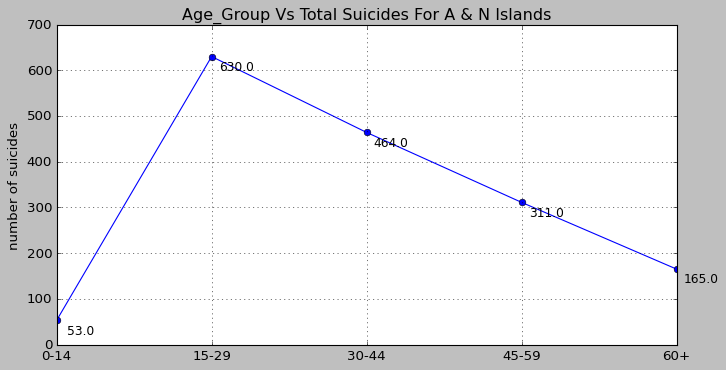

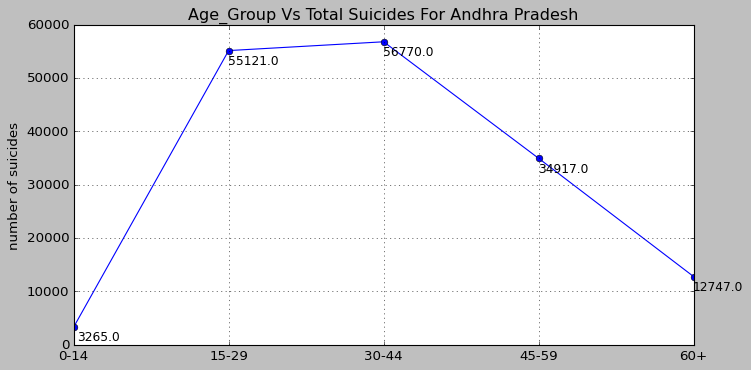

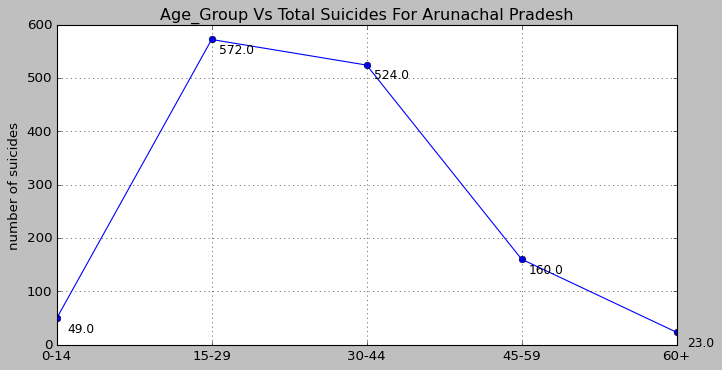

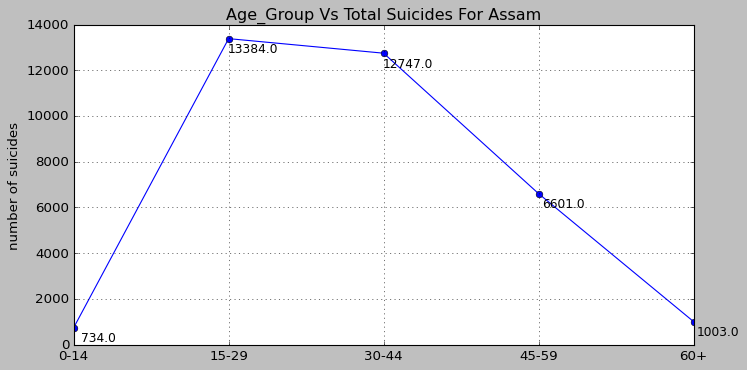

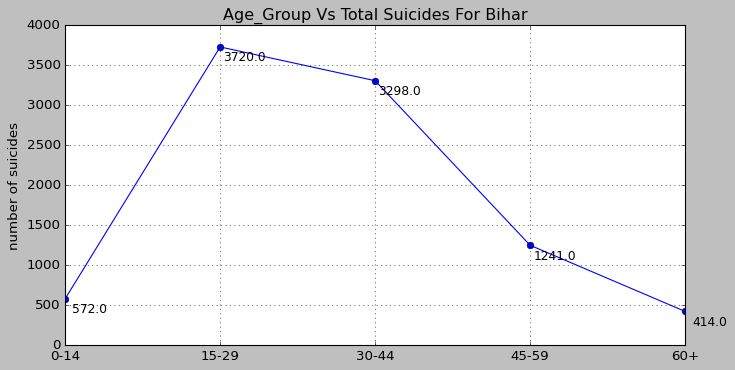

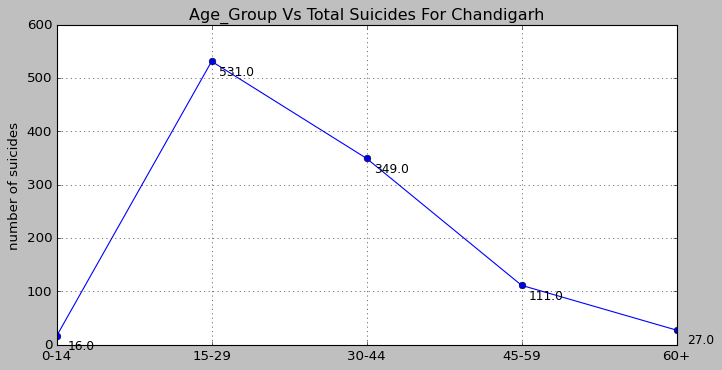

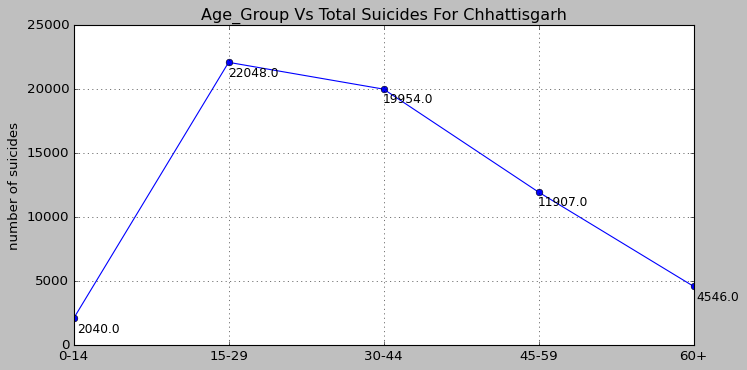

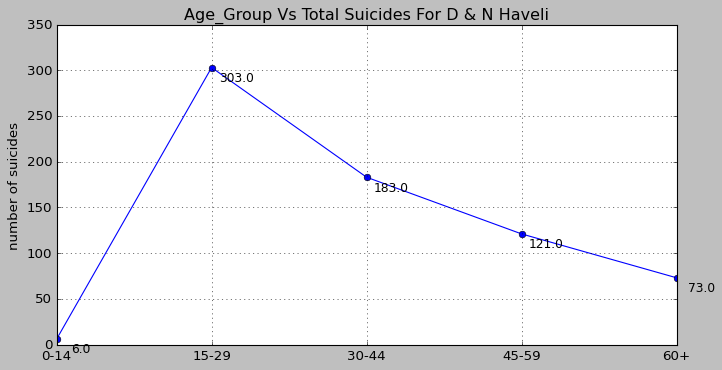

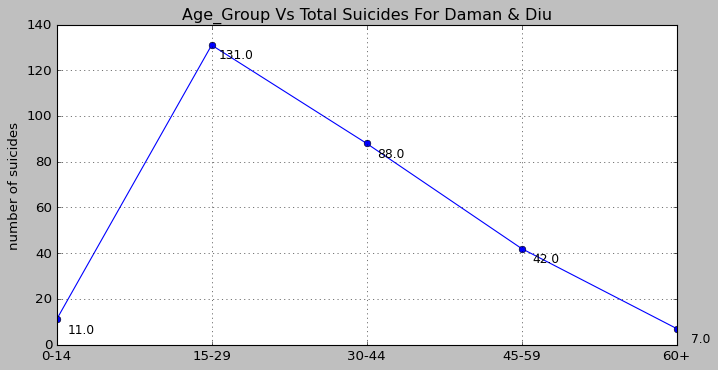

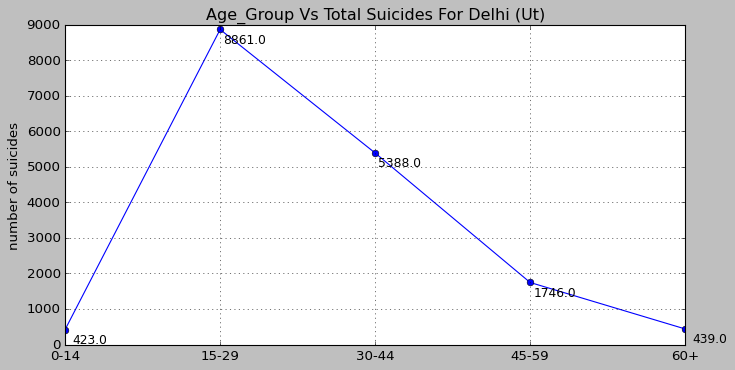

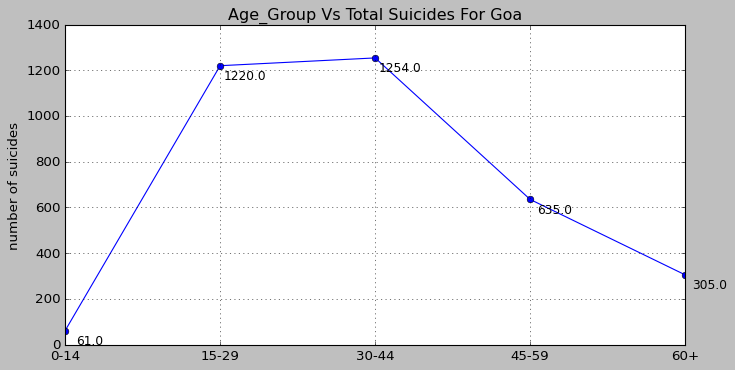

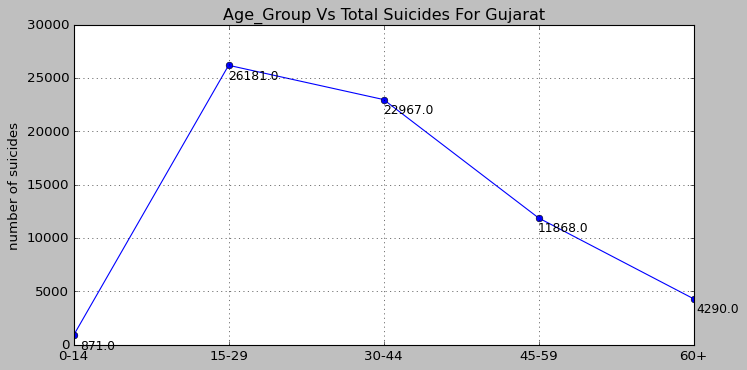

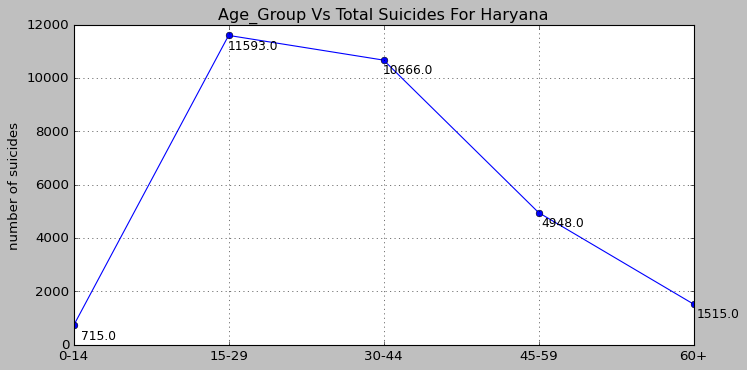

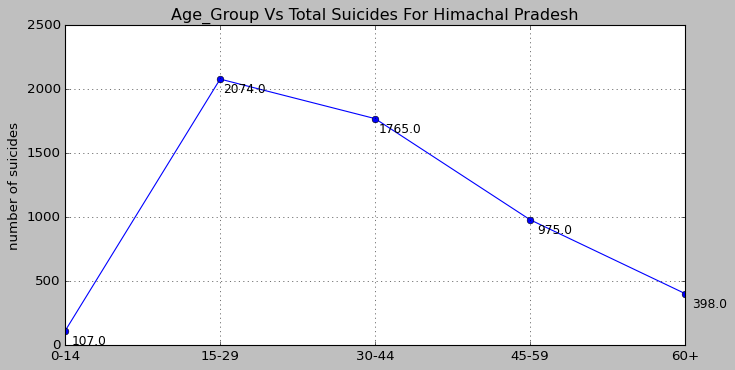

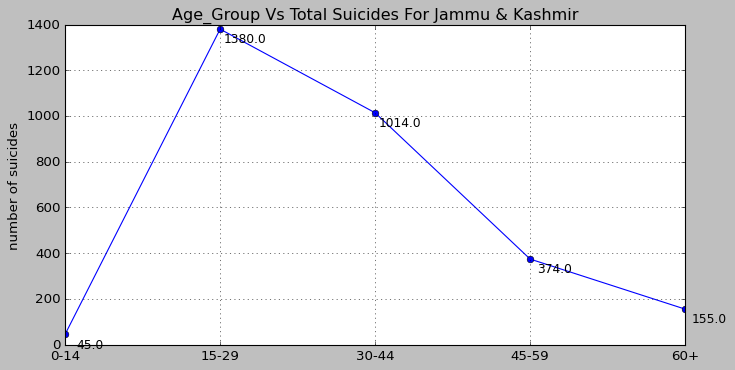

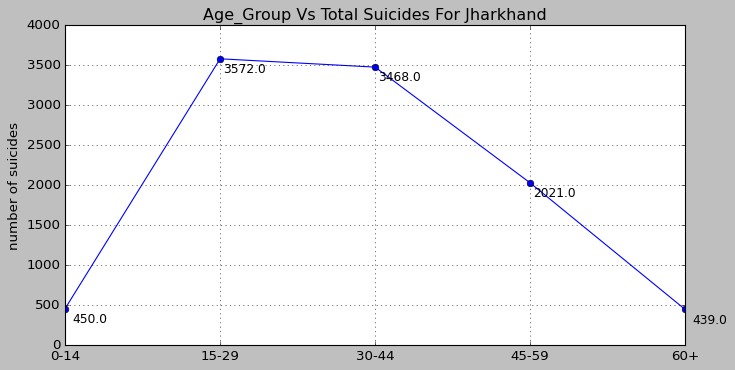

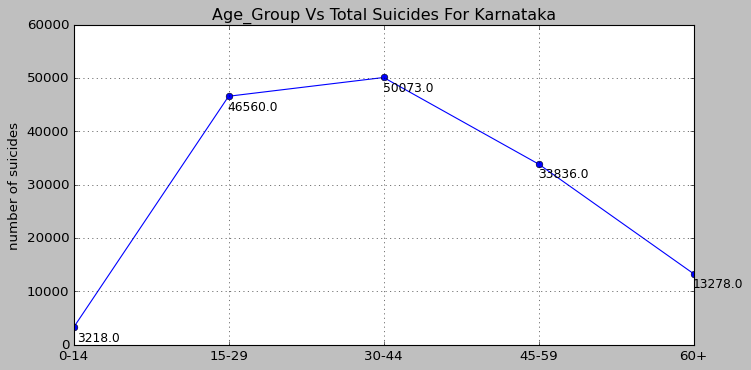

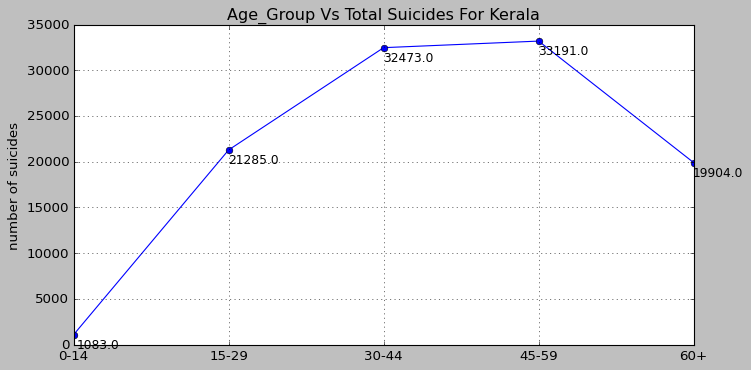

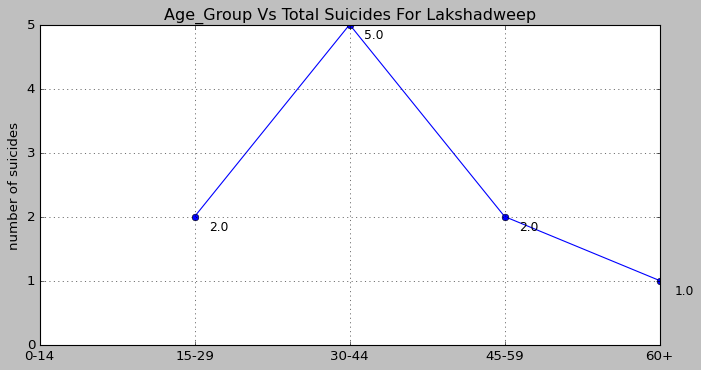

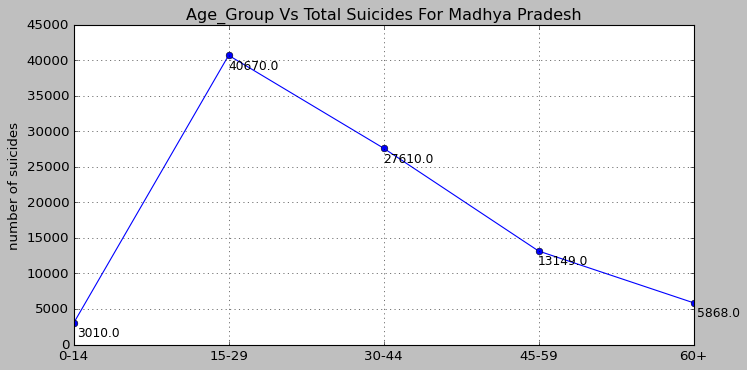

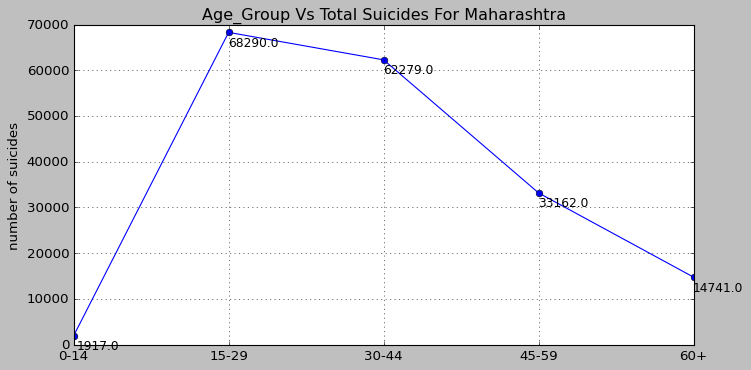

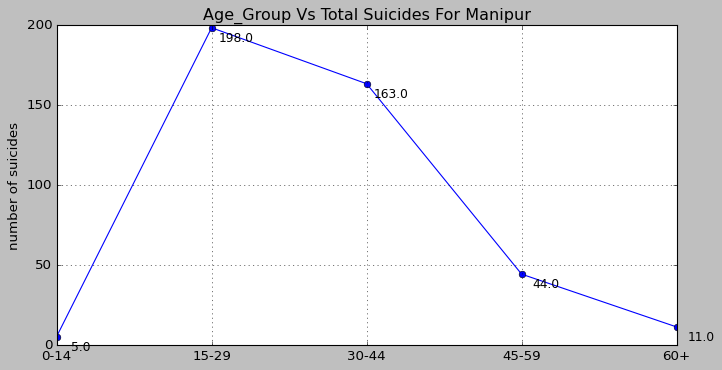

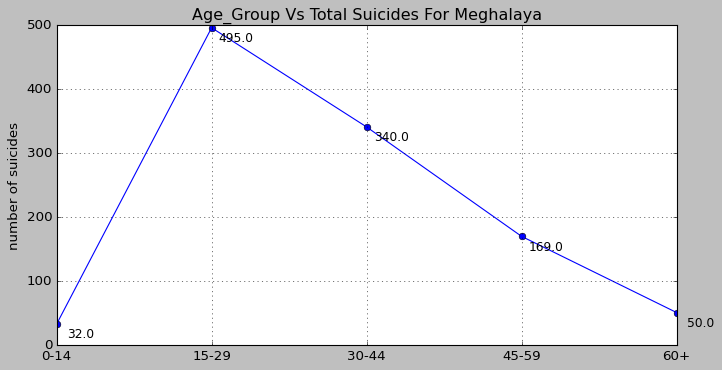

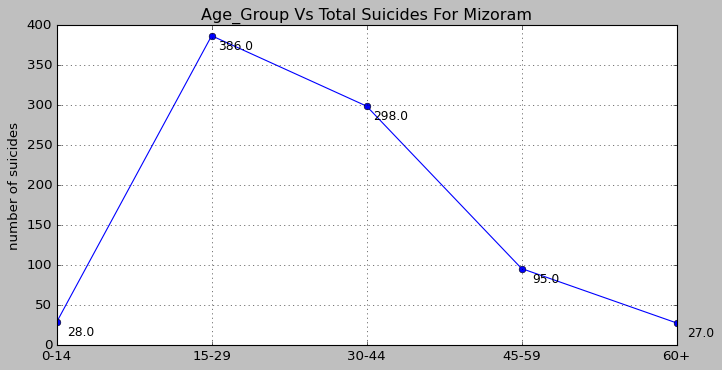

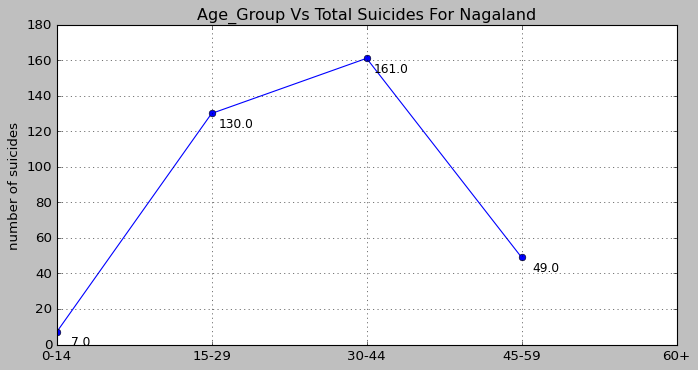

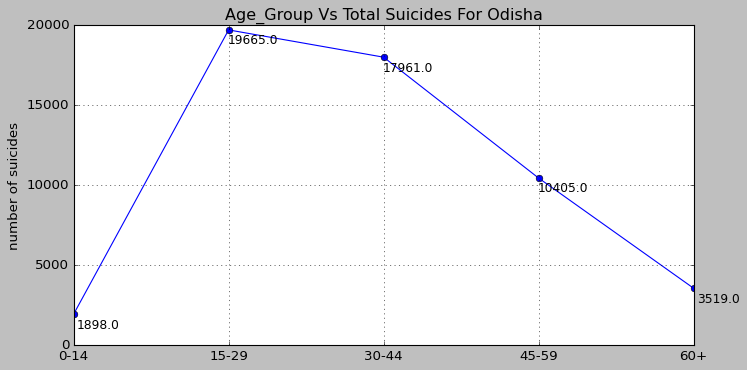

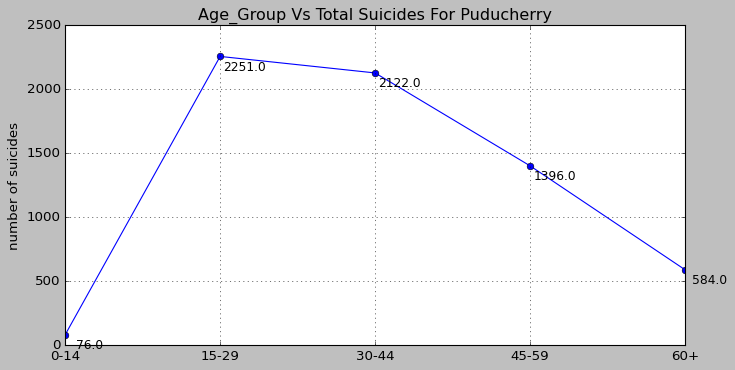

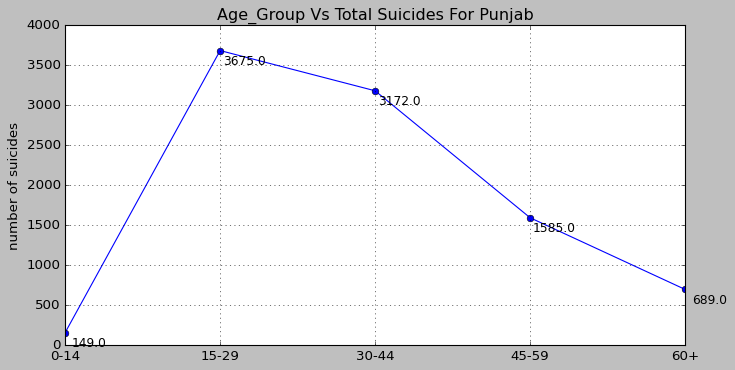

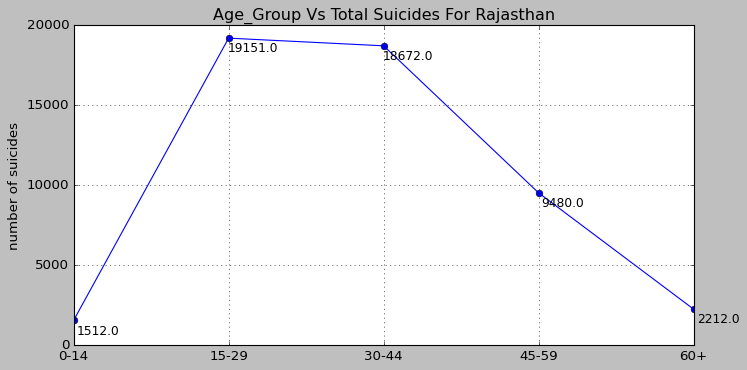

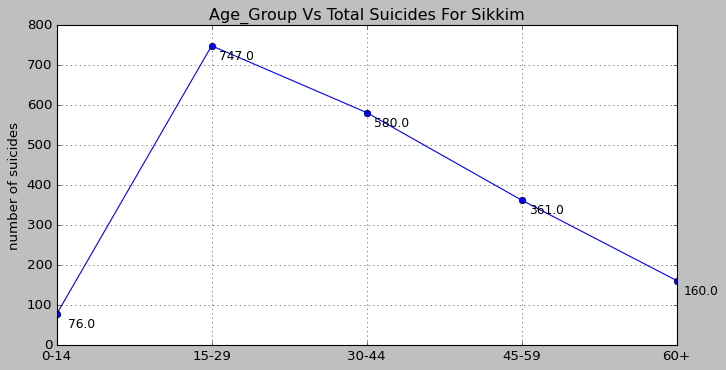

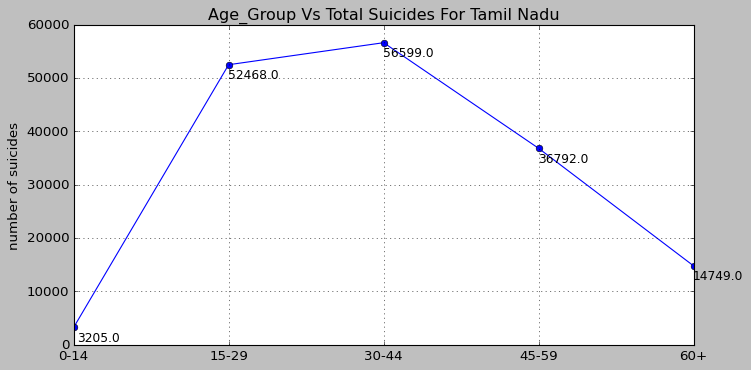

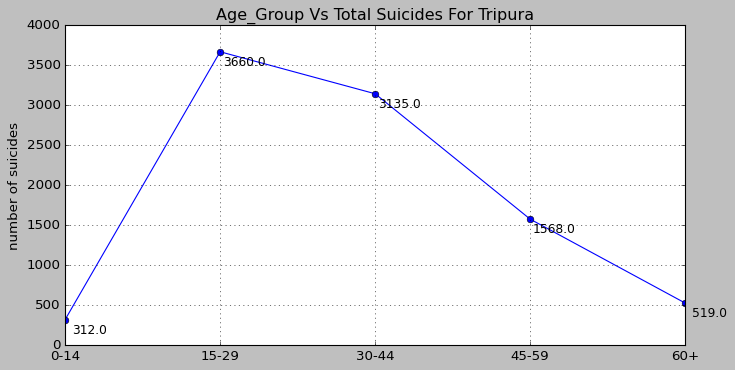

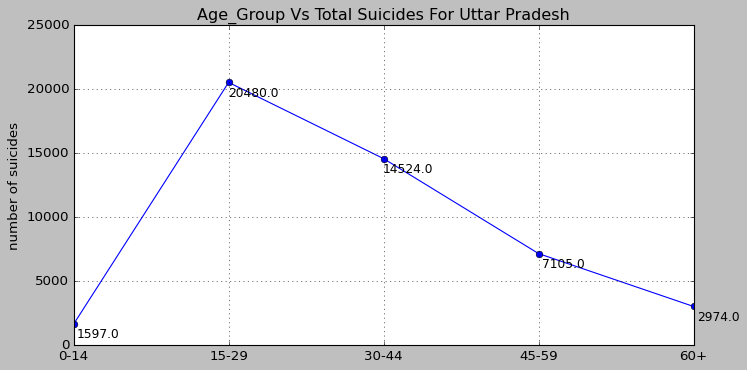

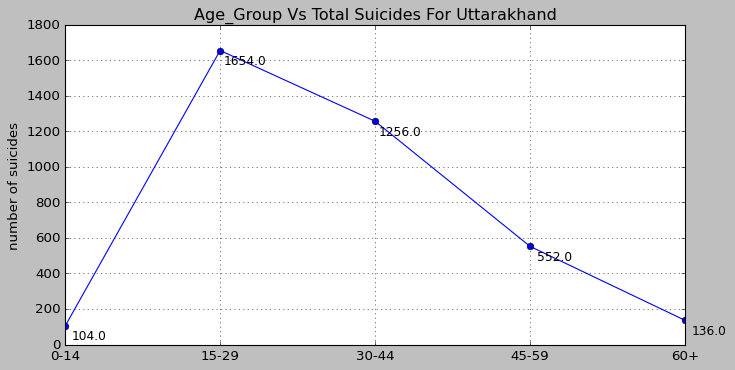

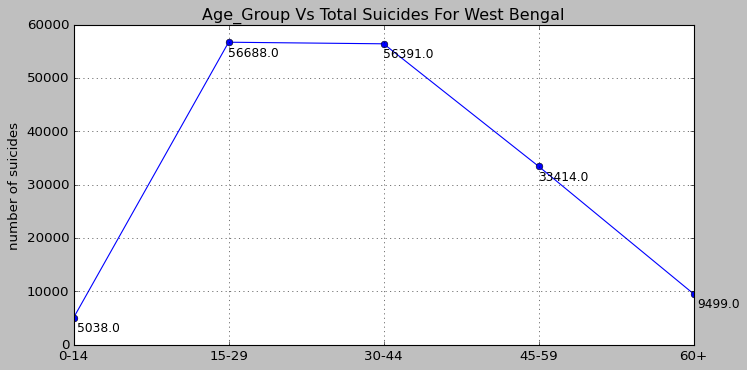

In [10]:

for s in states:
  y=state_vs_age_group.loc[s]
  x=ages
  plt.figure(figsize=(10,5))
  plt.plot(x,y,marker='o')

  for xi, yi in zip(x, y):
        plt.annotate(text=str(yi), xy=(xi, yi), textcoords="offset points", xytext=(22,-12), ha='center', fontsize=11)

  plt.xticks(x,x)
  plt.title(f'Age_Group Vs Total Suicides For {s}')
  plt.ylabel('number of suicides')
  plt.grid()
  plt.ylim(0,)
  #plt.savefig(f'/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/age_group vs total suicides for all states/Age_Group_Vs_Total_Suicides_For_{s.replace(" ","_")}')
  plt.show()


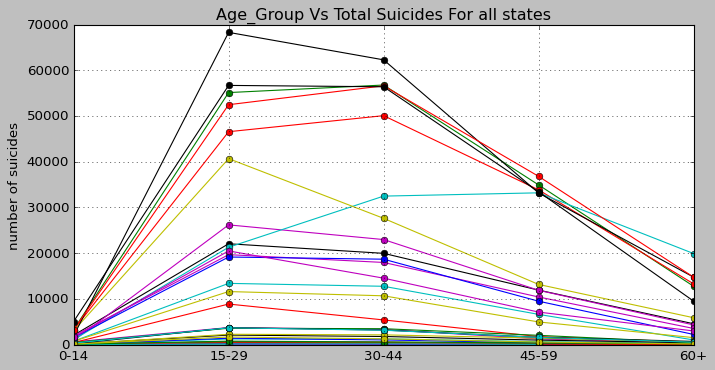

In [11]:
plt.figure(figsize=(10,5))
for s in states:
  y=state_vs_age_group.loc[s]
  x=ages

  plt.plot(x,y,marker='o')

plt.xticks(x,x)
plt.title(f'Age_Group Vs Total Suicides For all states')
plt.ylabel('number of suicides')
plt.grid()
plt.ylim(0,)
plt.show()


##2. Year with the highest recorded suicides


In [12]:
data.groupby('year')['total'].sum().sort_values(ascending=False).head(1)

,total
year,
2011,135585


##3. State with the fastest growth rate and growth rate for all states and top 5 state in context of growth rate


In [13]:
growth_rate=[]
for state in states:
  growth_rate.append(round(((state_vs_year.loc[state,2012]-state_vs_year.loc[state,2001])/state_vs_year.loc[state,2001])*100,2))

growth_rate_for_states=pd.DataFrame({'Growth Rate(%)':growth_rate},index=states)

state_with_fastest_growth_rate=growth_rate_for_states.fillna(0).sort_values(by='Growth Rate(%)',ascending=False).head(1)

top_5_gorwth_rate_state=growth_rate_for_states.fillna(0).sort_values(by='Growth Rate(%)',ascending=False).head()

In [14]:
growth_rate_for_states

,Growth Rate(%)
A & N Islands,-6.20
Andhra Pradesh,35.32
Arunachal Pradesh,17.12
Assam,23.31
Bihar,25.87
Chandigarh,62.86
Chhattisgarh,40.47
D & N Haveli,32.00
Daman & Diu,157.14
Delhi (Ut),53.27


In [15]:
top_5_gorwth_rate_state

,Growth Rate(%)
Jharkhand,427.60
Mizoram,220.37
Jammu & Kashmir,170.59
Daman & Diu,157.14
Sikkim,92.55


In [16]:
state_with_fastest_growth_rate

,Growth Rate(%)
Jharkhand,427.6


##4. State with a most declining trend


In [17]:
#yearly_growth_rate_for_states
yearly_growth_rate={}
for state in states:
  growth_rate=[]
  for i in range(1,len(years)):
    growth_rate.append(round((state_vs_year.loc[state,years[i]]-state_vs_year.loc[state,years[i-1]])/state_vs_year.loc[state,years[i-1]]*100,2))
    yearly_growth_rate[state]=growth_rate

yearly_growth_rate=pd.DataFrame({'Yearly Growth Rate(%)':list(yearly_growth_rate.values())},index=list(yearly_growth_rate.keys()))

In [18]:
'''
for state in states:
  x=years[1:]
  y=yearly_growth_rate.loc[state,'Yearly Growth Rate(%)']

  plt.figure(figsize=(10,5))

  plt.plot(x,y)

  plt.xticks(x,x)
  plt.title(f"yearly growth rate for {state}")
  plt.ylabel('Growth Rate(%)')
  plt.show()
'''
# this is not efficient way to find trend.
# so now we try to find it by avg of yeraly grwoth rate
yearly_avg_growth_rate=[]
for state in states:
  yearly_avg_growth_rate.append(sum(yearly_growth_rate.loc[state,'Yearly Growth Rate(%)'])/len(yearly_growth_rate.loc[state,'Yearly Growth Rate(%)']))
yearly_avg_growth_rate_df=pd.DataFrame({'avg yearlt growth rate(%)':yearly_avg_growth_rate},index=states)

# this is correct approach
yearly_avg_growth_rate_df.sort_values(by='avg yearlt growth rate(%)').head()

,avg yearlt growth rate(%)
Kerala,-1.054545
Tripura,0.261818
Puducherry,0.309091
A & N Islands,0.315455
Karnataka,0.680000


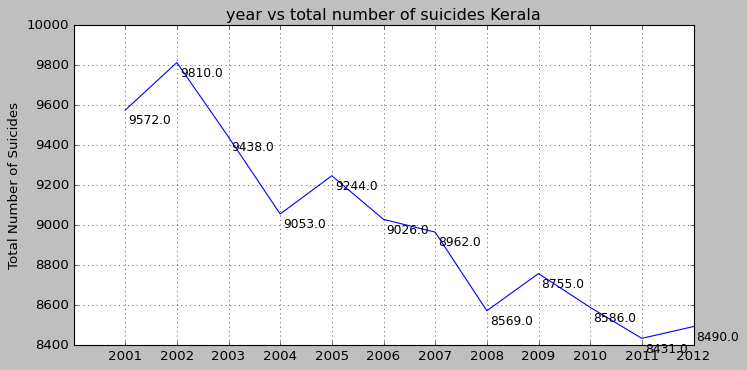

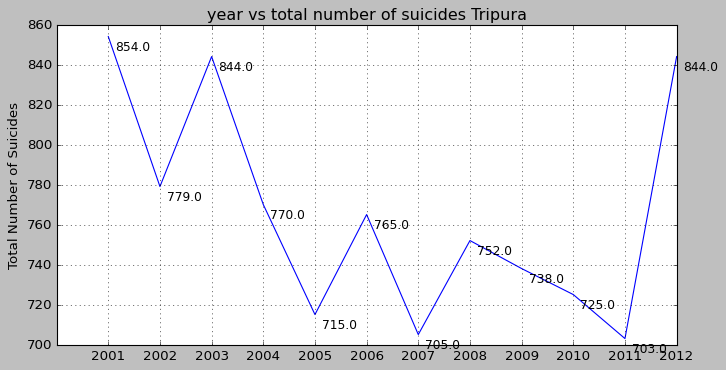

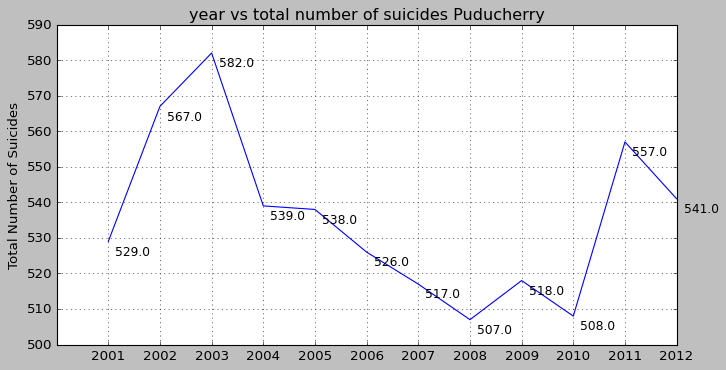

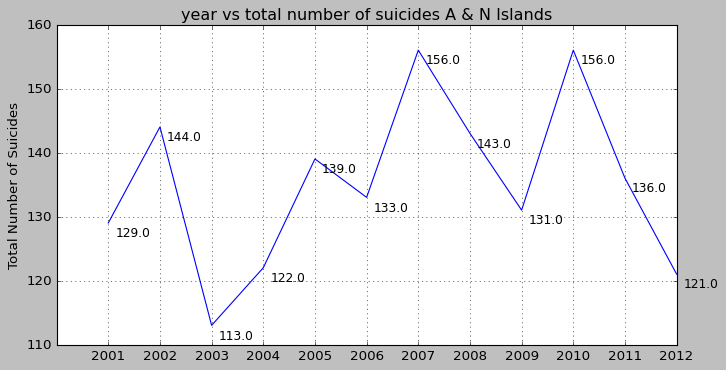

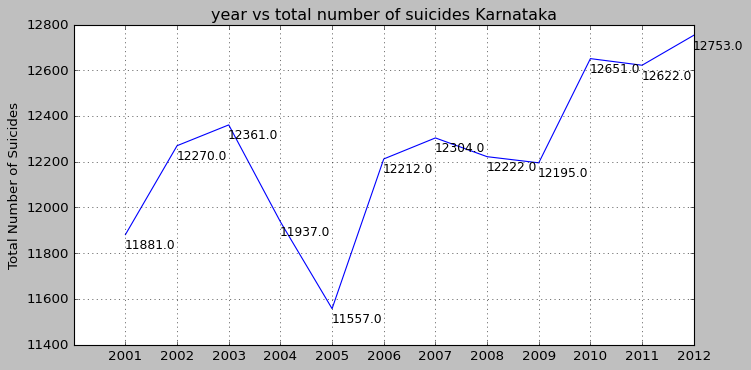

In [19]:
# now we can confirm our answer by seeing few graphs
for state in yearly_avg_growth_rate_df.sort_values(by='avg yearlt growth rate(%)').head().index:
  x=years
  y=state_vs_year.loc[state]

  plt.figure(figsize=(10,5))
  plt.plot(x,y)

  for xi, yi in zip(x, y):
        plt.annotate(text=str(yi), xy=(xi, yi), textcoords="offset points", xytext=(22,-12), ha='center', fontsize=11)

  plt.xticks(x,x)
  plt.title(f"year vs total number of suicides {state}")
  plt.ylabel("Total Number of Suicides")
  plt.grid()
  plt.show()

here we can see that kerala has declining trend

##5. Top 5 State with the highest child suicide count


In [20]:
state_vs_age_group.loc[:,'0-14'].sort_values(ascending=False).head()

,0-14
state,
West Bengal,5038.0
Andhra Pradesh,3265.0
Karnataka,3218.0
Tamil Nadu,3205.0
Madhya Pradesh,3010.0


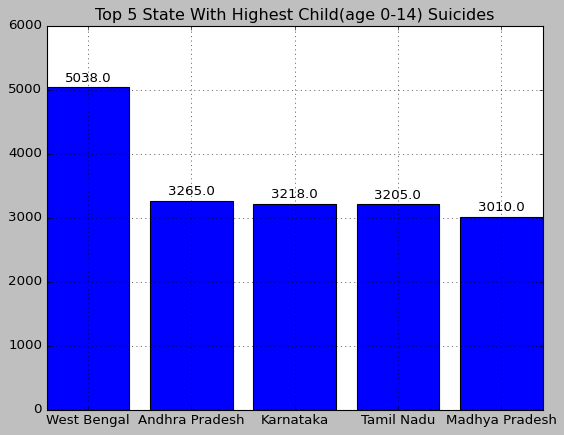

In [21]:
plt.bar(x=state_vs_age_group.loc[:,'0-14'].sort_values(ascending=False).head().index,height=state_vs_age_group.loc[:,'0-14'].sort_values(ascending=False).head())
plt.title('Top 5 State With Highest Child(age 0-14) Suicides')

x=state_vs_age_group.loc[:,'0-14'].sort_values(ascending=False).head().index
y=state_vs_age_group.loc[:,'0-14'].sort_values(ascending=False).head()
for xi,yi in zip(x,y):
  plt.annotate(text=str(yi),xy=(xi,yi),xytext=(0,5),ha="center",textcoords="offset points")
plt.grid()

#plt.savefig('/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Top_5_State_With_Highest_Child_Suicides')

plt.show()

##6. State-wise average by year suicide count


In [22]:
(data.groupby('state')['total'].sum()/12).sort_values(ascending=False)

,total
state,
Maharashtra,15032.416667
Tamil Nadu,13651.083333
Andhra Pradesh,13568.333333
West Bengal,13419.166667
Karnataka,12247.083333
Kerala,8994.666667
Madhya Pradesh,7525.583333
Gujarat,5514.750000
Chhattisgarh,5041.250000


##7. States with the highest male and female suicide counts


In [23]:
state_with_highest_female_suicides=data.groupby(['state','gender'])['total'].sum().unstack().sort_values(by=['Female'],ascending=False).head(1)
state_with_highest_male_suicides=data.groupby(['state','gender'])['total'].sum().unstack().sort_values(by=['Male'],ascending=False).head(1)


In [24]:
state_with_highest_male_suicides

gender,Female,Male
state,,
Maharashtra,58635,121754


In [25]:
state_with_highest_female_suicides

gender,Female,Male
state,,
West Bengal,69299,91731


##8.in which year did each individual state record its highest count?(with all details)

In [26]:
idx=data.groupby('state')['total'].idxmax()
data.loc[idx].sort_values(by='total',ascending=False).reset_index(drop=True)

,state,year,type_code,type,gender,age_group,total
0,Maharashtra,2012,Causes,Family Problems,Male,30-44,1557
1,West Bengal,2006,Causes,Family Problems,Male,30-44,1465
2,Tamil Nadu,2010,Causes,Family Problems,Male,30-44,1287
3,Kerala,2012,Causes,Family Problems,Male,45-59,1039
4,Karnataka,2008,Causes,Other Causes (Please Specity),Male,30-44,903
5,Andhra Pradesh,2008,Causes,Other Causes (Please Specity),Male,30-44,816
6,Madhya Pradesh,2008,Causes,Dowry Dispute,Female,15-29,611
7,Haryana,2011,Causes,Other Causes (Please Specity),Male,15-29,564
8,Chhattisgarh,2010,Causes,Causes Not known,Male,30-44,563
9,Rajasthan,2007,Causes,Other Causes (Please Specity),Male,30-44,540


## 9. State wise Total suicides accorss all years

In [28]:
data.groupby("state")["total"].sum().sort_values(ascending=False)

,total
state,
Maharashtra,180389
Tamil Nadu,163813
Andhra Pradesh,162820
West Bengal,161030
Karnataka,146965
Kerala,107936
Madhya Pradesh,90307
Gujarat,66177
Chhattisgarh,60495
